This note book is used to ready data for building ML models for Bacteria

In [1]:
import os
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

### Import chEMBL data for all viruses

In [2]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')

In [3]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'AllBacteriaData_chEMBL_combined.csv')
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus
0,CHEMBL221435,CC1=C[C@H]2[C@@H](C(C)(C)O)CC[C@@](C)(O)[C@H]2CC1,C15H26O2,XOUUSQWJTXEKIT-PWNZVWSESA-N,InChI=1S/C15H26O2/c1-10-5-6-13-11(9-10)12(14(2...,238.37,Small molecule,NaN,NaN,NaN,...,2.0,1.0,0.69,17.0,0.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,'=',...,2.0,3.0,0.89,24.0,2.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,'=',...,0.0,7.0,0.25,32.0,4.0,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,'=',...,12.0,15.0,0.07,65.0,3.0,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,'=',...,1.0,6.0,0.40,27.0,3.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313310,CHEMBL1916860,O=S(=O)(c1ccccc1)N1N=C(c2ccccc2O)C[C@H]1c1ccc(...,C21H18N2O4S,OCMIHTWLNUIYFA-FQEVSTJZSA-N,InChI=1S/C21H18N2O4S/c24-16-12-10-15(11-13-16)...,394.45,Small molecule,16000.00,nM,'>',...,2.0,4.0,0.71,28.0,3.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv
313311,CHEMBL1916846,NC(=O)N1N=C(c2ccccc2O)C[C@H]1c1ccc(O)cc1,C16H15N3O3,UWJMRDJIYBMPLL-AWEZNQCLSA-N,InChI=1S/C16H15N3O3/c17-16(22)19-14(10-5-7-11(...,297.31,Small molecule,31000.00,nM,'>',...,3.0,2.0,0.79,22.0,2.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv
313312,CHEMBL1916842,Oc1ccc([C@@H]2CC(c3ccccc3O)=NN2)cc1,C15H14N2O2,RMOCLYAXEFWGCG-ZDUSSCGKSA-N,InChI=1S/C15H14N2O2/c18-11-7-5-10(6-8-11)13-9-...,254.29,Small molecule,20000.00,nM,'=',...,3.0,2.0,0.77,19.0,2.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv
313313,CHEMBL1916852,N=C(N)N1N=C(c2ccccc2O)C[C@H]1c1ccc(O)cc1,C16H16N4O2,FSZWTHSQGICTMA-AWEZNQCLSA-N,InChI=1S/C16H16N4O2/c17-16(18)20-14(10-5-7-11(...,296.33,Small molecule,NaN,NaN,NaN,...,4.0,2.0,0.50,22.0,2.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv


### Count Standard Type

/tmp/ipykernel_1732525/2953830666.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


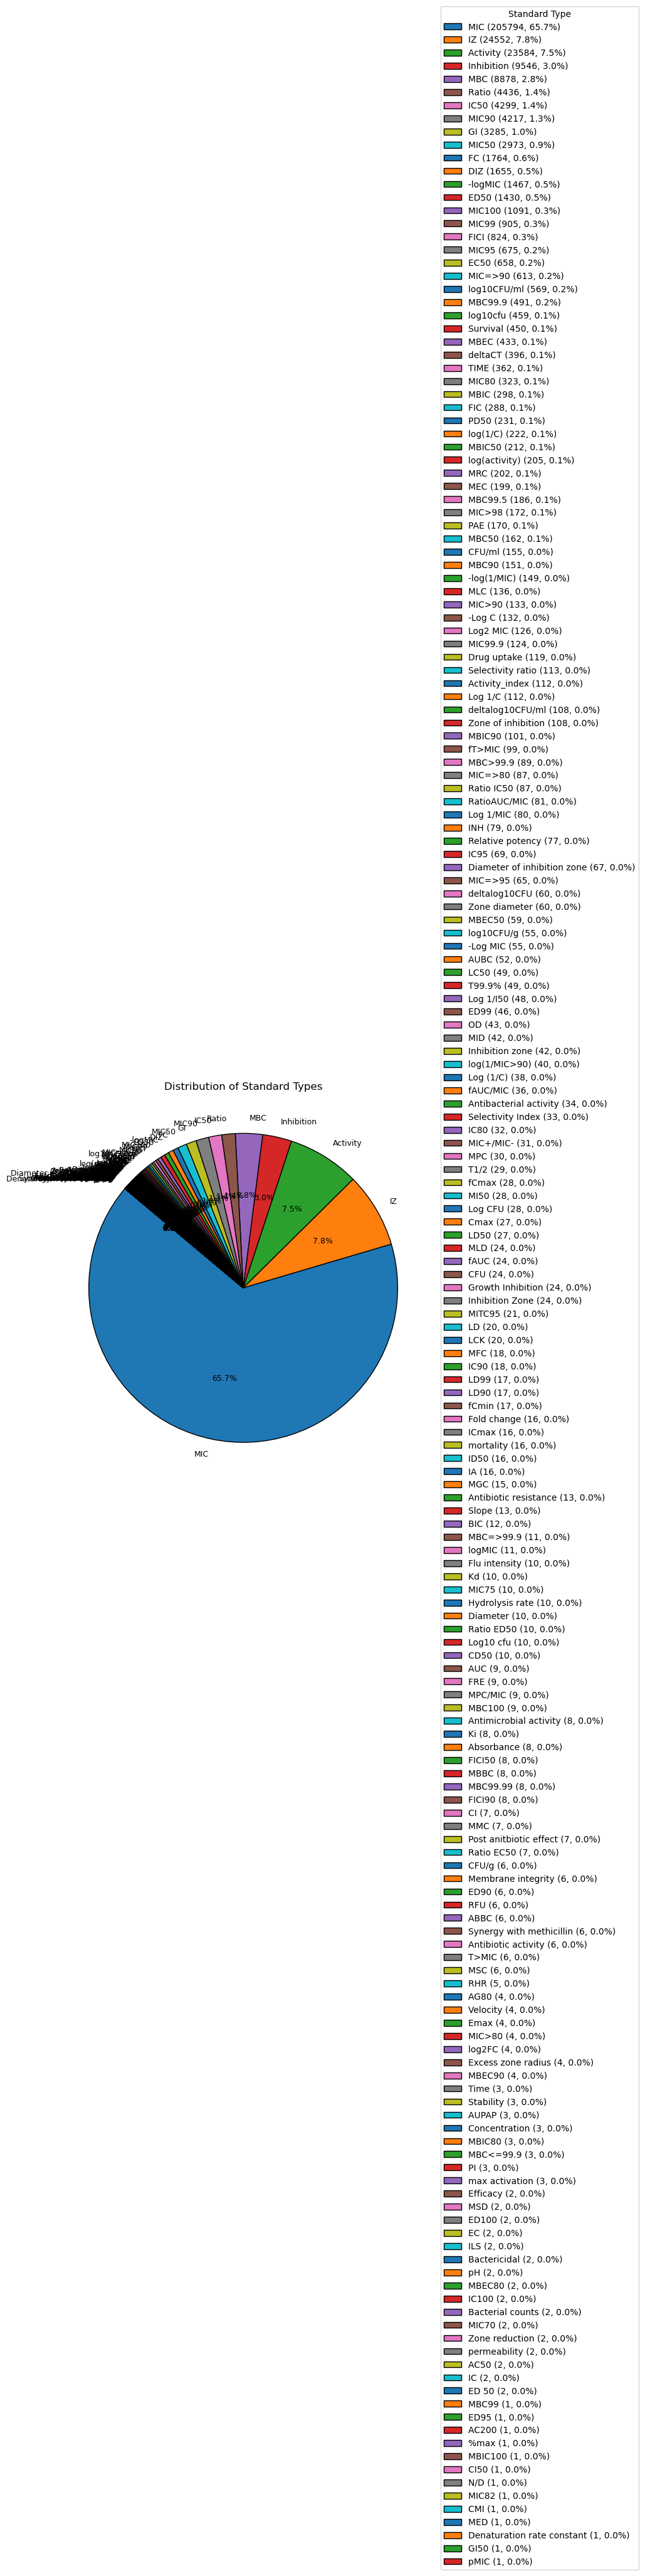

In [4]:
# Count occurrences of each Standard Type
type_counts = allBacteriaData_chEMBL["standard_type"].value_counts()
total = type_counts.sum()

# Legend labels with counts and percentages
legend_labels = [
    f"{stype} ({count}, {count/total:.1%})"
    for stype, count in type_counts.items()
]

# Plot pie chart with inside labels showing just Standard Type
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,  # short labels inside slices
    autopct='%1.1f%%',         # show % inside too
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 9}
)

# Legend with full details
plt.legend(
    wedges,
    legend_labels,
    title="Standard Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Distribution of Standard Types")
plt.tight_layout()
plt.show()

In [5]:
# Count and sort standard_type values
typeCounts = allBacteriaData_chEMBL["standard_type"].value_counts(dropna=True)
total = typeCounts.sum()

print("Standard Types sorted by frequency:\n")
for stype, count in typeCounts.items():
    pct = (count / total) * 100
    print(f"{stype:30s} : {count:6d}  ({pct:5.2f}%)")

Standard Types sorted by frequency:

MIC                            : 205794  (65.68%)
IZ                             :  24552  ( 7.84%)
Activity                       :  23584  ( 7.53%)
Inhibition                     :   9546  ( 3.05%)
MBC                            :   8878  ( 2.83%)
Ratio                          :   4436  ( 1.42%)
IC50                           :   4299  ( 1.37%)
MIC90                          :   4217  ( 1.35%)
GI                             :   3285  ( 1.05%)
MIC50                          :   2973  ( 0.95%)
FC                             :   1764  ( 0.56%)
DIZ                            :   1655  ( 0.53%)
-logMIC                        :   1467  ( 0.47%)
ED50                           :   1430  ( 0.46%)
MIC100                         :   1091  ( 0.35%)
MIC99                          :    905  ( 0.29%)
FICI                           :    824  ( 0.26%)
MIC95                          :    675  ( 0.22%)
EC50                           :    658  ( 0.21%)
MIC=>90      

### Bioactivity for antibacterial ML 

**Use as targets (convert to µM, then log-transform):**
- **MIC / MBC** → core potency. Convert to µM (from µg/mL using molecular weight), then use **pMIC / pMBC = −log10(M)**.  
- **IC50 / EC50 (or GI50)** → dose–response potency. Convert to µM, then **pIC50 / pEC50 = −log10(M)**.  
- **MIC50/90/95/99/100** → concentrations but summarize **isolate populations**; keep separate from single-compound QSAR.

**Avoid as single-agent QSAR targets (different meaning/units):**
- **IZ / DIZ** (zone diameters, mm) — plate/diffusion dependent; not directly comparable to MIC.  
- **% Inhibition / “Activity”** at a single dose — ambiguous without fixed assay concentration/time.  
- **FICI** — synergy index for **combination** studies (use only in combo/synergy models).  
- **FC / Ratio** — unitless, context-dependent.  
- **ED50** (mg/kg, in vivo) — different domain; model separately.

**Preprocessing essentials**
- **Unit harmonization:** bring all concentration endpoints to **µM** using the **parent compound** molecular weight (not salt).  
  \[
  \text{µM} = \frac{\text{µg/mL} \times 1000}{\text{MW (g/mol)}}
  \]
- **Log transform:** for regression stability,  
  \[
  pX = -\log_{10}(\text{M}) \quad\Rightarrow\quad pX = -\log_{10}(\text{µM}) + 6
  \]
- **Censoring:** handle “\<”, “\>”, “≤”, “≥” via **censored regression (Tobit)** or by **thresholded classification**.  
- **Assay coherence:** do not mix endpoints (e.g., MIC with %GI) unless you include **assay type/conditions** as features.  
- **Deduplicate/aggregate:** after normalization, use the **median** across replicates per compound–strain–assay.

**Bottom line:**  
For single-compound antibacterial QSAR, prioritize **pMIC** and **pIC50/pEC50**. Keep IZ/DIZ, FICI, ED50, and MIC90-style cohort metrics for separate or specialized analyses.


### Converts all standard types (IC50/EC50/IC90/EC90) to µM

In [6]:
import re
import numpy as np
import pandas as pd

# -------- Patterns for antibacterial potency endpoints --------
MIC_FAMILY_PATTERNS = [
    r'\bMIC\b', r'\bMIC\d+\b', r'\bMIC[=>]?\d+\b', r'\bMIC\+\s*/\s*MIC-\b'
]
MBC_FAMILY_PATTERNS = [
    r'\bMBC\b', r'\bMBC\d+(\.\d+)?\b', r'\bMBC[=>]?\d+(\.\d+)?\b', r'\bMBC99\.9\b', r'\bMBC99\.99\b'
]
DOSE_RESPONSE_PATTERNS = [
    r'\b[IE]C\s*\d+\b',   # IC50, EC90, etc.
    r'\bAC\s*\d+\b',      # AC50 etc (rare but present)
]
BINDING_PATTERNS = [r'\bK[di]\b']  # Ki, Kd

# Common log-scale forms we can invert to µM without needing units
LOG_POTENCY_PATTERNS = [
    r'^-?log\s*\(?\s*1\s*/\s*C\)?$',   # -log(1/C), log(1/C), Log (1/C)
    r'^-?log\s*mic$', r'^log2\s*mic$', r'^-?log\s*\(?\s*1\s*/\s*mic\)?$',
    r'^p?mic$', r'^-?log\s*mic>?\d+$'
]

def _norm(s):
    return re.sub(r'\s+', '', str(s or '')).strip().lower()

def isMicLike(stdType: str) -> bool:
    s = _norm(stdType)
    return any(re.search(p, s, flags=re.IGNORECASE) for p in MIC_FAMILY_PATTERNS)

def isMbcLike(stdType: str) -> bool:
    s = _norm(stdType)
    return any(re.search(p, s, flags=re.IGNORECASE) for p in MBC_FAMILY_PATTERNS)

def isDoseResponse(stdType: str) -> bool:
    s = _norm(stdType)
    return any(re.search(p, s, flags=re.IGNORECASE) for p in DOSE_RESPONSE_PATTERNS)

def isBinding(stdType: str) -> bool:
    s = _norm(stdType)
    return any(re.search(p, s, flags=re.IGNORECASE) for p in BINDING_PATTERNS)

def isLogPotency(stdType: str) -> bool:
    s = _norm(stdType)
    return any(re.fullmatch(p, s, flags=re.IGNORECASE) for p in LOG_POTENCY_PATTERNS)

# -------- Unit maps --------
UNIT_TO_uM = {  # molar → µM
    "m": 1e6, "mol/l": 1e6,
    "mm": 1e3, "mmol/l": 1e3,
    "um": 1.0, "μm": 1.0, "µm": 1.0, "umol/l": 1.0, "μmol/l": 1.0, "µmol/l": 1.0,
    "nm": 1e-3, "nmol/l": 1e-3,
    "pm": 1e-6, "pmol/l": 1e-6,
    "molar": 1e6, "mmolar": 1e3, "umolar": 1.0, "nmolar": 1e-3, "pmolar": 1e-6
}

# mass/volume to µg/mL
MASSVOL_TO_ug_per_mL = {
    "µg/ml": 1.0, "μg/ml": 1.0, "ug/ml": 1.0, "mcg/ml": 1.0,
    "mg/l": 1.0,                 # mg/L == µg/mL
    "ng/ml": 1e-3,
    "mg/ml": 1e3,
    "g/l": 1e3,                  # g/L == 1000 µg/mL
    "µg/l": 1e-3, "μg/l": 1e-3, "ug/l": 1e-3
}

def toMicroMolarFromMolarUnits(value, unitStr):
    if pd.isna(value) or pd.isna(unitStr): return np.nan
    factor = UNIT_TO_uM.get(_norm(unitStr))
    if factor is None: return np.nan
    try: return float(value) * factor
    except Exception: return np.nan

def toMicroMolarFromMassPerVolume(value, unitStr, molecularWeight_g_per_mol):
    """
    Convert mass/volume concentration (e.g., µg/mL, mg/L) to µM:
        µM = (µg/mL * 1000) / MW(g/mol)
    """
    if pd.isna(value) or pd.isna(unitStr) or pd.isna(molecularWeight_g_per_mol): return np.nan
    factorToUgPerMl = MASSVOL_TO_ug_per_mL.get(_norm(unitStr))
    if factorToUgPerMl is None: return np.nan
    try:
        ugPerMl = float(value) * factorToUgPerMl
        return (ugPerMl * 1000.0) / float(molecularWeight_g_per_mol)
    except Exception:
        return np.nan

def invertLogToMicroMolar(stdType, stdValue):
    """
    Handle log-scale potency forms commonly found in antibacterial datasets.
    Assumes base-10 logs:
      - pMIC or -log(M) → µM = 10^(6 - pX)
      - log(1/C) or Log 1/MIC → same as pX if C is in molar units.
    We cannot reliably invert 'log2 MIC' without knowing the exact definition; skip it.
    """
    if pd.isna(stdValue): return np.nan
    s = _norm(stdType)
    try:
        val = float(stdValue)
    except Exception:
        return np.nan

    # pMIC / -log(MIC in M) / -log(1/C) → treat all as pX on base-10 molar scale
    if re.fullmatch(r'(?:p?mic|[-]?logmic|[-]?log\(1/c\)|log\(1/mic\)|log1/mic|log1/c)', s):
        return 10.0 ** (6.0 - val)

    # '-Log MIC' frequently means -log10(MIC in M)
    if s in ('-logmic', '-logmic>90', '-log(1/mic)', '-log(1/c)', 'log(1/c)'):
        return 10.0 ** (6.0 - val)

    # Not safely invertible (e.g., log2 MIC, unspecified base)
    return np.nan

# -------- Main conversion pipeline --------

def convertToMicroMolarAntibacterial(allVirusData_chEMBL: pd.DataFrame) -> pd.DataFrame:
    DF = allBacteriaData_chEMBL.copy()

    # Ensure we have helpful lowercase unit/type columns for matching
    DF["standard_type_norm"] = DF.get("standard_type", "").astype(str)
    DF["standard_units_norm"] = DF.get("standard_units", "").astype(str)

    # Detect which rows are concentration-like
    DF["is_mic_like"] = DF["standard_type_norm"].apply(isMicLike)
    DF["is_mbc_like"] = DF["standard_type_norm"].apply(isMbcLike)
    DF["is_ic_ec_like"] = DF["standard_type_norm"].apply(isDoseResponse)
    DF["is_binding_like"] = DF["standard_type_norm"].apply(isBinding)
    DF["is_log_potency"] = DF["standard_type_norm"].apply(isLogPotency)

    # Numeric standard_value?
    DF["standard_value_num"] = pd.to_numeric(DF.get("standard_value"), errors="coerce")

    # Molar conversions (IC/EC/Ki/Kd or MIC/MBC already in molar units)
    DF["uM_from_molar"] = DF.apply(
        lambda row: toMicroMolarFromMolarUnits(row["standard_value_num"], row["standard_units"])
        if (row["is_ic_ec_like"] or row["is_binding_like"] or row["is_mic_like"] or row["is_mbc_like"])
        else np.nan,
        axis=1
    )

    # Mass/volume conversions (MIC/MBC usually reported in µg/mL, mg/L, etc.)
    # Expect a molecular weight column; try common names
    mwCol = None
    for cand in ["molecular_weight", "props__full_mwt", "full_mwt", "mw", "mwt"]:
        if cand in DF.columns:
            mwCol = cand
            break
    if mwCol is None:
        DF["uM_from_massvol"] = np.nan
    else:
        DF["uM_from_massvol"] = DF.apply(
            lambda row: toMicroMolarFromMassPerVolume(
                row["standard_value_num"], row["standard_units"], row[mwCol]
            ) if (row["is_mic_like"] or row["is_mbc_like"]) else np.nan,
            axis=1
        )

    # Log-scale inversion (e.g., -logMIC, pMIC, log(1/C))
    DF["uM_from_log"] = DF.apply(
        lambda row: invertLogToMicroMolar(row["standard_type"], row["standard_value"])
        if row["is_log_potency"] else np.nan,
        axis=1
    )

    # Combine into a single value_uM in priority order:
    # 1) explicit molar units, 2) mass/volume (needs MW), 3) log inversion
    DF["value_uM"] = DF["uM_from_molar"]
    DF.loc[DF["value_uM"].isna(), "value_uM"] = DF.loc[DF["value_uM"].isna(), "uM_from_massvol"]
    DF.loc[DF["value_uM"].isna(), "value_uM"] = DF.loc[DF["value_uM"].isna(), "uM_from_log"]

    # pPotency (−log10(M))
    DF["pPotency"] = np.where(
        DF["value_uM"].notna() & (DF["value_uM"] > 0),
        -np.log10(DF["value_uM"] * 1e-6),  # convert µM → M then take -log10
        np.nan
    )

    # Convenience flags
    DF["is_convertible_to_uM"] = DF["value_uM"].notna()
    DF["potency_family"] = np.select(
        [
            DF["is_mic_like"], DF["is_mbc_like"], DF["is_ic_ec_like"], DF["is_binding_like"], DF["is_log_potency"]
        ],
        ["MIC", "MBC", "IC/EC", "Ki/Kd", "logPotency"],
        default="other"
    )

    # Clean up helper columns if you like (keep pPotency/value_uM & a few breadcrumbs)
    dropCols = [
        "standard_type_norm","standard_units_norm","standard_value_num",
        "uM_from_molar","uM_from_massvol","uM_from_log",
        "is_mic_like","is_mbc_like","is_ic_ec_like","is_binding_like","is_log_potency"
    ]
    DF = DF.drop(columns=dropCols, errors="ignore")
    return DF

# ---------------- Use it ----------------
allBacteriaData_chEMBL_uM = convertToMicroMolarAntibacterial(allBacteriaData_chEMBL)
print("Convertible rows:", int(allBacteriaData_chEMBL_uM["is_convertible_to_uM"].sum()))
allBacteriaData_chEMBL_uM.head()

Convertible rows: 209244


/users/sghosh6/.conda/envs/pubchemData/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/users/sghosh6/.conda/envs/pubchemData/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family
0,CHEMBL221435,CC1=C[C@H]2[C@@H](C(C)(C)O)CC[C@@](C)(O)[C@H]2CC1,C15H26O2,XOUUSQWJTXEKIT-PWNZVWSESA-N,InChI=1S/C15H26O2/c1-10-5-6-13-11(9-10)12(14(2...,238.37,Small molecule,NaN,NaN,NaN,...,0.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,NaN,NaN,False,other
1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,'=',...,2.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.25,True,MIC
2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,'=',...,4.0,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.00,True,MIC
3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,'=',...,3.0,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.50,True,MIC
4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,'=',...,3.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.00,True,MIC


### Keep only those rows which have Convertible standards

In [7]:
allBacteriaData_chEMBL_uM = allBacteriaData_chEMBL_uM.dropna(subset=['value_uM'])
allBacteriaData_chEMBL_uM

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family
1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,'=',...,2.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC
2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,'=',...,4.0,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC
3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,'=',...,3.0,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC
4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,'=',...,3.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC
5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,'=',...,3.0,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313307,CHEMBL22,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,C14H18N4O3,IEDVJHCEMCRBQM-UHFFFAOYSA-N,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,290.32,Small molecule,1.00,ug.mL-1,'<=',...,2.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e+05,1.000000,True,MIC
313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,'=',...,1.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC
313310,CHEMBL1916860,O=S(=O)(c1ccccc1)N1N=C(c2ccccc2O)C[C@H]1c1ccc(...,C21H18N2O4S,OCMIHTWLNUIYFA-FQEVSTJZSA-N,InChI=1S/C21H18N2O4S/c24-16-12-10-15(11-13-16)...,394.45,Small molecule,16000.00,nM,'>',...,3.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.600000e+01,4.795880,True,IC/EC
313311,CHEMBL1916846,NC(=O)N1N=C(c2ccccc2O)C[C@H]1c1ccc(O)cc1,C16H15N3O3,UWJMRDJIYBMPLL-AWEZNQCLSA-N,InChI=1S/C16H15N3O3/c17-16(22)19-14(10-5-7-11(...,297.31,Small molecule,31000.00,nM,'>',...,2.0,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.100000e+01,4.508638,True,IC/EC


### Add p-scale (pPotency) conversion to bring all concentrations (µM) onto a logarithmic scale

In [8]:
dfp = allBacteriaData_chEMBL_uM.copy()  # your frame with `value_uM`

# 1) Make sure value_uM is numeric
dfp["value_uM"] = pd.to_numeric(dfp.get("value_uM"), errors="coerce")

# 2) Normalize the relation column (handles "'", spaces, synonyms, unicode)
def normalize_relation(rel):
    if pd.isna(rel):
        return None
    s = str(rel).strip()

    # remove surrounding quotes if present
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1].strip()

    s = s.strip().lower()

    # map HTML/unicode and synonyms
    s = s.replace("&lt;", "<").replace("&gt;", ">")
    s = s.replace("≤", "<=").replace("≥", ">=")
    s = s.replace("==", "=")

    # word synonyms
    if s in {"eq", "equals", "equal"}:
        s = "="
    elif s in {"lt", "less", "lessthan"}:
        s = "<"
    elif s in {"le", "lessequal", "lessthanorequal"}:
        s = "<="
    elif s in {"gt", "greater", "greaterthan"}:
        s = ">"
    elif s in {"ge", "greaterequal", "greaterthanorequal"}:
        s = ">="
    elif s in {"approx", "~", "≈"}:
        s = "="

    # keep only one of: =, <, >, <=, >= ; else None
    if s in {"=", "<", ">", "<=", ">="}:
        return s
    return None

dfp["relation_norm"] = dfp.get("standard_relation").apply(normalize_relation)

# 3) Safe log10
def safe_log10(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    out[mask] = np.log10(x[mask])
    return out

# 4) Compute pPotency (p = 6 - log10(µM))
p_from_uM = 6.0 - safe_log10(dfp["value_uM"])

# exact if relation is '=' or missing
has_exact = (dfp["relation_norm"].isna()) | (dfp["relation_norm"].eq('='))

# lower/upper bounds for censored values
is_lt  = dfp["relation_norm"].eq('<')
is_le  = dfp["relation_norm"].eq('<=')
is_gt  = dfp["relation_norm"].eq('>')
is_ge  = dfp["relation_norm"].eq('>=')

dfp["pPotency"]       = np.where(has_exact, p_from_uM, np.nan)
dfp["pPotencyLower"]  = np.where(is_lt | is_le, p_from_uM, np.nan)  # true conc < / ≤ value → pPotency > bound
dfp["pPotencyUpper"]  = np.where(is_gt | is_ge, p_from_uM, np.nan)  # true conc > / ≥ value → pPotency < bound
dfp["pPotencyMid"]    = dfp[["pPotency", "pPotencyLower", "pPotencyUpper"]].median(axis=1, skipna=True)

# 5) Summary
n_exact = int(dfp["pPotency"].notna().sum())
n_lower = int(dfp["pPotencyLower"].notna().sum())
n_upper = int(dfp["pPotencyUpper"].notna().sum())
print(f"Exact pPotency rows: {n_exact}")
print(f"Censored lower-bound rows (relation '<' or '<='): {n_lower}")
print(f"Censored upper-bound rows (relation '>' or '>='): {n_upper}")

# Replace the working frame if you want
allBacteriaData_chEMBL_uM = dfp
allBacteriaData_chEMBL_uM

Exact pPotency rows: 164194
Censored lower-bound rows (relation '<' or '<='): 4221
Censored upper-bound rows (relation '>' or '>='): 35136


,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,relation_norm,pPotencyLower,pPotencyUpper,pPotencyMid
1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,'=',...,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.25000,True,MIC,=,NaN,NaN,0.250000
2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,'=',...,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.00000,True,MIC,=,NaN,NaN,100.000000
3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,'=',...,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.50000,True,MIC,=,NaN,NaN,1.500000
4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,'=',...,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.00000,True,MIC,=,NaN,NaN,16.000000
5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,'=',...,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.00000,True,MIC,=,NaN,NaN,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313307,CHEMBL22,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,C14H18N4O3,IEDVJHCEMCRBQM-UHFFFAOYSA-N,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,290.32,Small molecule,1.00,ug.mL-1,'<=',...,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e+05,NaN,True,MIC,<=,1.0,NaN,1.000000
313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,'=',...,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.39794,True,IC/EC,=,NaN,NaN,5.397940
313310,CHEMBL1916860,O=S(=O)(c1ccccc1)N1N=C(c2ccccc2O)C[C@H]1c1ccc(...,C21H18N2O4S,OCMIHTWLNUIYFA-FQEVSTJZSA-N,InChI=1S/C21H18N2O4S/c24-16-12-10-15(11-13-16)...,394.45,Small molecule,16000.00,nM,'>',...,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.600000e+01,NaN,True,IC/EC,>,NaN,4.795880,4.795880
313311,CHEMBL1916846,NC(=O)N1N=C(c2ccccc2O)C[C@H]1c1ccc(O)cc1,C16H15N3O3,UWJMRDJIYBMPLL-AWEZNQCLSA-N,InChI=1S/C16H15N3O3/c17-16(22)19-14(10-5-7-11(...,297.31,Small molecule,31000.00,nM,'>',...,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.100000e+01,NaN,True,IC/EC,>,NaN,4.508638,4.508638


In [9]:
allBacteriaData_chEMBL_uM = allBacteriaData_chEMBL_uM.dropna(subset=['pPotency'])
allBacteriaData_chEMBL_uM.shape

(164194, 33)

In [10]:
allBacteriaData_chEMBL_uM = allBacteriaData_chEMBL_uM.dropna(subset=['smiles'])
allBacteriaData_chEMBL_uM.shape

(163422, 33)

### some data cleaning

In [11]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['pPotency']))

163422

In [12]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['pPotencyLower']))

0

In [13]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['pPotencyUpper']))

0

In [14]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['pPotency']))

163422

In [15]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['pPotencyMid']))

163422

In [16]:
len(allBacteriaData_chEMBL_uM.dropna(subset=['smiles']))

163422

In [16]:
allBacteriaData_chEMBL_uM = allBacteriaData_chEMBL_uM.drop(columns=['relation_norm','pPotencyLower', 'pPotencyUpper'], errors='ignore')
allBacteriaData_chEMBL_uM

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,'=',...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC,0.250000
2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,'=',...,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC,100.000000
3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,'=',...,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC,1.500000
4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,'=',...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,'=',...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.54,Small molecule,32000.00,nM,'=',...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.200000e+01,4.494850,True,MIC,4.494850
313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2681.45,Small molecule,46600.00,nM,'=',...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.660000e+01,4.331614,True,MIC,4.331614
313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.35,NaN,256.00,ug.mL-1,'=',...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e-250,256.000000,True,MIC,256.000000
313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,'=',...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC,5.397940


In [17]:
allBacteriaData_chEMBL_uM.to_csv(os.path.join(modelBuildingDataDir, "allBacteriaData_chEMBL_uM.csv"))